# Aspirin Hydrolysis Curve Fits

the data is from 
"The hydrolysis of aspirin." L.J. Edwards, *Trans. Faraday Soc.*, **1950**, *46*, 723-735. https://doi.org/10.1039/TF9504600723

## Load Data

The data table from the above paper was made into a csv file (`Edwards1950.csv`). The file contains pH and k_obs values. It is read into a dataframe with the pH va;ues as the index series.  Then a $\log{(K_{obs})}$ series is created and a series for $[H^+]$

In [15]:
#!pip install uncertainties
#!pip install lmfit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un               # tool set for handling uncertainties
from uncertainties import unumpy as unp  # a replacement for numpy 

import lmfit     

!mkdir plots

################################################################################
### Set global variables. Set flag accordingly
################################################################################

#github = True  
github = False  

if github:
    data_path = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_10/data/"
    image_path = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_10/images/"
    github_data_location = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"
    github_styles_location = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/styles/"
else:
    data_path = "data/"
    image_path = "images/"
    github_data_location = "/Users/blink/github/LFER-QSAR/data/"
    github_styles_location = "../../styles/"

    

################################################################################
### Read data set. The fields are separated by commas; comments are enabled  
################################################################################

df = pd.read_csv(data_path + "Edwards1950.csv", 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="pH", 
                 comment = "#") 

################################################################################
### Process data  
################################################################################

df["logk"] = np.log10(df["k_obs"])        # get log(K) from K
df["H"]=10**(-df.index)                   # get [H] from pH
df.sort_values(by=['pH'], inplace=True)   # one value was out of order, sort to fix.

display(df.head())

mkdir: plots: File exists


,k_obs,logk,H
pH,,,
0.53,0.5780,-0.238072,0.295121
1.00,0.1900,-0.721246,0.100000
1.33,0.0835,-1.078314,0.046774
1.80,0.0450,-1.346787,0.015849
2.48,0.0267,-1.573489,0.003311


## Plot the Data

Below is code that will plot the log-log plot for the pH-rate profile. We will plot $\log{k_{obs}}$ vs. $pH$

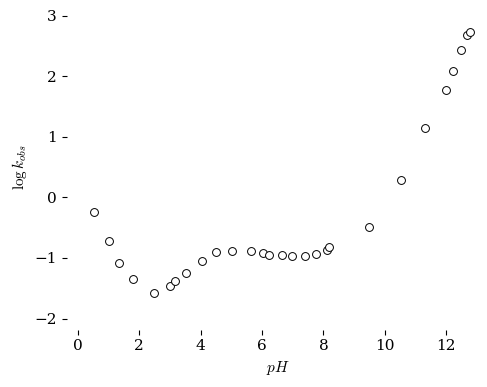

In [16]:
################################################################################
### Choose x and y for plot
################################################################################

x = df.index             # pH values are in the index of the dataframe
y = np.array(df["logk"]) # log(k_obs) values

################################################################################
### Setup a figure with two plots side-by-side and choose a stylesheet
################################################################################

# reset the default style settings for matplotlib so we always start from the same stylesheet
plt.rcdefaults()  # reset the default style settings for matplotlib so we always start from the same stylesheet

# Choose a style sheet for the plot. The stylesheets are in the "styles" folder of the GitHub repository.
plt.style.use(github_styles_location + "tufte.mplstyle")        
#plt.style.use(github_styles_location + "S2_classic2.mplstyle")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

################################################################################
### Plot the data    
################################################################################

ax.scatter(x, y, 
           marker = "o", s=32, 
           c="white", edgecolor = "black",
           linewidth = 0.7, label=r"$\log{k_{obs}}$", zorder=3)
   
################################################################################
### Set labels and scale 
################################################################################

ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))
ax.set(ylabel=r"$\log{k_{obs}}$", 
       xlabel=r"$pH$",
       xlim=[0,13],                  
       ylim=[-2,3],     
      )
#ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

################################################################################
### Output the final plot 
################################################################################

fig.savefig("plots/01_plot.pdf")   # use this to save the figure in PDF format
plt.show()                            # output the plot to the screen

## Bootstraping

Bootstrapping is considered to be better at determining the confidence interval for complicated nonlinear functions.

First we define the components of the pH-rate profile

## Defining Functions

The functions below describe each mechanism in the model. And then a final model is created that calculates the sum of the rate constant contributions from each component to give the total observed rate constant, $k_{obs}$. 

In [17]:
################################################################################
### Functions that define each component's rate constant
################################################################################

def genbase(pH, pKa=3.55, k= 0.117): # fit the intramolecular general base-catalyzed rate
    Ka = 10**(-pKa)
    H = 10**(-pH)
    frac_base = Ka/(H + Ka)
    rateconst = k * frac_base
    return rateconst

def genacid(pH, pKa=3.55, k=0.01):   # fit the water rate (kinetically indistiguishable from GA)
    Ka = 10**(-pKa)
    H = 10**(-pH)
    frac_acid = H/(Ka + H) # The fraction in the protonated, neutral form is H/(Ka + H)
    rateconst = k * frac_acid
    return rateconst

def specificacid(pH, k= 1.9):   # fit the specific acid-catalyzed rate 
    H = 10**(-pH)
    rateconst = (H*k)
    return rateconst    
    
def specificbase(pH, k=7500, pKa=3.55, pKW=14):  # fit the specific base-catalyzed rate
    H = 10**(-pH)
    KW = 10**(-pKW)
    OH = KW / H
    Ka = 10**(-pKa)
    frac_base = Ka/(H + Ka)
    rateconst = (OH*k*frac_base)
    return rateconst   

################################################################################
### Function that defines the model - used in curve fit
################################################################################

def aspirin_model(pH, ka = 1.9, kb=0.01, kc = 0.12, kd = 7500, pKa = 3.55, pKW = 14):    
    """
    aspirin_model(pH, ka, kb, kc, kd, pKa, pKW) - model for the pH-rate profile of aspirin hydrolysis
    pH is an array of pH values
    returns an array of k_obs values
    """
    H = 10**(-pH)
    k_obs = specificacid(pH, ka) + genacid(pH, pKa, kb) + genbase(pH, pKa, kc) + specificbase(pH, kd, pKa, pKW)
    return np.log10(k_obs)



### Test the Code

Below I plot the data against values that are known. The plot generated from the functions matches the data. 

Always test early and often. If you make any improvements to the code, test again. Test, test, test.

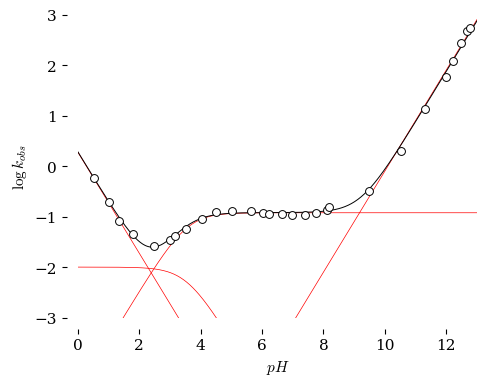

In [18]:
################################################################################
### Choose x and y for plot
################################################################################

x = df.index             # pH values are in the index of the dataframe
y = np.array(df["logk"]) # log(k_obs) values

x_fit = np.linspace(0, 13, 500)  # create a smooth x array for plotting the model
y_fit = aspirin_model(x_fit)     # No parameters given. Default values are used for the model. 

################################################################################
### Setup a figure with two plots side-by-side and choose a stylesheet
################################################################################

# reset the default style settings for matplotlib so we always start from the same stylesheet
plt.rcParams.update(plt.rcParamsDefault)

# Choose a style sheet for the plot. The stylesheets are in the "styles" folder of the GitHub repository.
plt.style.use(github_styles_location + "tufte.mplstyle")        
#plt.style.use(github_styles_location + "S2_classic2.mplstyle")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

################################################################################
### Plot the data    
################################################################################

ax.scatter(x, y, 
           marker = "o", s=32, 
           c="white", edgecolor = "black",
           linewidth = 0.7, label=r"$\log{k_{obs}}$", zorder=3)
   

################################################################################
### Plot the results of known values in black    
################################################################################

ax.plot(x_fit, y_fit, 
        color="black", linewidth=0.7, zorder=2)

################################################################################
### Plot the results of known values for components in red    
################################################################################

y_fit = np.log10(specificacid(x_fit, k=1.88))
ax.plot(x_fit, y_fit,
        color="red", linewidth=0.5, zorder=1)

y_fit = np.log10(genacid(x_fit, pKa=3.55, k=0.01))
ax.plot(x_fit, y_fit,
        color="red", linewidth=0.5, zorder=1)

y_fit = np.log10(genbase(x_fit, pKa=3.55, k=0.119))
ax.plot(x_fit, y_fit,
        color="red", linewidth=0.5, zorder=1)

y_fit = np.log10(specificbase(x_fit, k=7970, pKa=3.55, pKW=14))
ax.plot(x_fit, y_fit,
        color="red", linewidth=0.5, zorder=1)
 
################################################################################
### Set labels and scale 
################################################################################

ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))

ax.set(ylabel=r"$\log{k_{obs}}$", 
       xlabel=r"$pH$",
       xlim=[0,13],                  
       ylim=[-3,3],     
      )
#ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

################################################################################
### Output the final plot 
################################################################################

fig.savefig("plots/02_plot_test.pdf")   # use this to save the figure in PDF format
plt.show()                            # output the plot to the screen

### Perform a Curve Fit

Using the model, let us fit it against the data using LMFit

In [19]:
from lmfit import Model

x = df.index             # pH values are in the index of the dataframe
y = np.array(df["logk"]) # log(k_obs) values

gmodel = Model(aspirin_model, nan_policy='omit')
params = gmodel.make_params(                    # initial values and constraints
                        ka = dict(value = 1.5, min = 1E-15, max = 100),
                        kb = dict(value = 0.015, min = 1E-15, max = 100),
                        kc = dict(value = 0.15, min = 1E-15, max = 100),
                        kd = dict(value = 10000, min = 1, max = 100000),
                        pKa = dict(value = 4., min = 1, max = 10),
                        pKW = dict(value = 14.0, vary = False)
                        )    
# note: in fitting a model, all parameters must be named in the model function, 
# even if they are not varied. The parameters that are not varied can be set 
# to a fixed value in the make_params() call. The x variable must also be named 
# in the model function.
result = gmodel.fit(y, params, pH=x)

print(result.fit_report())

[[Model]]
    Model(aspirin_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 37
    # data points      = 28
    # variables        = 5
    chi-square         = 0.09112114
    reduced chi-square = 0.00396179
    Akaike info crit   = -150.377559
    Bayesian info crit = -143.716536
    R-squared          = 0.99816138
[[Variables]]
    ka:   1.74957493 +/- 0.17394188 (9.94%) (init = 1.5)
    kb:   0.01384847 +/- 0.00459635 (33.19%) (init = 0.015)
    kc:   0.11987210 +/- 0.00543026 (4.53%) (init = 0.15)
    kd:   7555.77819 +/- 405.072309 (5.36%) (init = 10000)
    pKa:  3.65409037 +/- 0.12326587 (3.37%) (init = 4)
    pKW:  14 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(kb, pKa) = +0.7450
    C(ka, kb)  = -0.5346
    C(kc, pKa) = +0.3992
    C(ka, pKa) = -0.3540
    C(kb, kc)  = +0.1261


## Calculate Line Fit and Uncertainty (Confidence Interval and Prediction Interval)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

###############################################################################
# Generate smooth curve
###############################################################################

x_fit = np.linspace(0, 13, 500)  # create a smooth x array for plotting the model

# Best-fit curve
y_fit = result.eval(pH=x_fit)

# Confidence intervals
ci = result.eval_uncertainty(pH=x_fit, sigma=0.95)  # 95% confidence interval. For 95% confidence interval, use sigma=1.96 for large sample sizes, but lmfit can use sigma=0.95 for 95% CI.

ci_upper = y_fit + ci
ci_lower = y_fit - ci

# Prediction intervals
se = result.eval_uncertainty(pH=x_fit, sigma=1)  # standard error of the fit
mse = result.redchi  # reduced chi-squared value from the fit (mean squared error)
se_pred = np.sqrt(se**2 + mse)

dof = result.ndata - result.nvarys # degrees of freedom = number of data points - number of fitted parameters
tval = t.ppf(0.975,dof)  # two-tailed t-value for 95% confidence interval

pi_lower = y_fit - tval * se_pred
pi_upper = y_fit + tval * se_pred

## Plot the line fit and confifence intervals

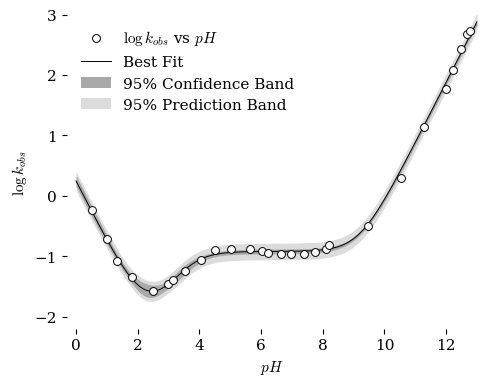

In [21]:
###############################################################################
# Plot
###############################################################################

################################################################################
### Setup a figure  and choose a stylesheet   
################################################################################
plt.rcdefaults()
plt.style.use(github_styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

ax.scatter(x, y, 
           marker = "o", s=32, 
           c="white", edgecolor = "black",
           linewidth = 0.7, label=r"$\log{k_{obs}}$ vs $pH$", zorder=4)



ax.plot(
    x_fit,
    y_fit,
    color="black",
    lw=0.7,
    label="Best Fit",
    zorder = 3
)

ax.fill_between(
    x_fit,
    ci_lower,
    ci_upper,
    linewidth = 0,
    facecolor="darkgray",
    edgecolor = "dimgray",
#    facecolor="lightskyblue",
#    edgecolor = "dodgerblue",
#    alpha=0.30,
    label="95% Confidence Band",
    zorder = 2

)

ax.fill_between(
    x_fit,
    pi_lower,
    pi_upper,
#    ls = "None",
    linewidth = 0,
    facecolor="gainsboro",
    edgecolor = "darkgray",
#    facecolor="honeydew",
#    edgecolor = "lightgreen",
#    alpha=0.30,
    label="95% Prediction Band",
    zorder = 1
)

ax.set(ylabel=r"$\log{k_{obs}}$", 
       xlabel=r"$pH$",
          xlim=[-0.3,13],                  
          ylim=[-2.2,3]
      )


plt.legend()
plt.tight_layout()
fig.savefig("plots/03_plot_LMFit_CI_PI.pdf")   # use this to save the figure in PDF format

plt.show()

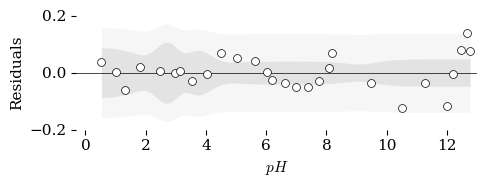

In [43]:
###############################################################################
# Generate smooth curve
###############################################################################

# Best-fit curve
y_fit = result.eval(pH=x_fit)

derr_upper = ci_upper - y_fit
derr_lower = y_fit - ci_lower

prediction_upper = pi_upper - y_fit
prediction_lower = y_fit - pi_lower

################################################################################
### Setup a figure  and choose a stylesheet   
################################################################################
plt.rcdefaults()
plt.style.use(github_styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,2))  

################################################################################
### Plot the data and the line fit.   
################################################################################

ax.axhline(0, linewidth = 0.5)

ax.scatter(x, y - result.eval(pH=x), 
           marker = "o", s=32, 
           color="white", edgecolor = "black",
           linewidth = 0.5, zorder=3)

################################################################################
### Set labels and scale 
################################################################################

ax.set(ylabel=r"Residuals", 
       xlabel=r"$pH$",
          xlim=[-0.3,13],                  
          ylim=[-0.2,0.2]
      )

#ax.margins(x=.07, y=.07, tight=True)  # add 7% empty space around outside of plot area   


# upper and lower bounds of uncertain kobs as float values

################################################################################
### Create Confidence band upper and lower bounds
################################################################################

ax.fill_between(pH_fit, -derr_upper, derr_lower, 
                   color="lightgray", alpha=0.5, zorder = 0,
                   linewidth=0, label="confidence interval")

# prediction inteerval bounds
ax.fill_between(pH_fit, -prediction_upper, prediction_lower,
                   color="lightgray", alpha=0.20, zorder = 0,
                   linewidth=0, label="prediction interval")

#############################
### Output the final plot ###
#############################

fig.savefig("plots/06_plot_pH3_LMFit_residuals.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots


## Bca Bootstrap

In [37]:
import numpy as np
import pandas as pd

from scipy.stats import fit, norm

def bca_bootstrap_parameters(
    model,
    result,
    x,
    nboot=5000,
    alpha=0.05,
    seed=123,
):
    """
    BCa bootstrap confidence intervals
    for LMFit parameters.

    Parameters
    ----------
    model : lmfit.Model

    result : lmfit.ModelResult

    x : ndarray
        Original x values (pH)

    nboot : int

    alpha : float
        0.05 -> 95% CI

    Returns
    -------
    DataFrame
    """

    rng = np.random.default_rng(seed)

    residuals = (
        result.data
        - result.best_fit
    )

    param_names = result.var_names

    theta_hat = {
        p: result.params[p].value
        for p in param_names
    }
    curve_samples = []
    # ----------------------------------------------------------
    # Bootstrap
    # ----------------------------------------------------------

    boot = {
        p: []
        for p in param_names
    }

    successes = 0

    for i in range(nboot):

        try:

            resampled = rng.choice(
                residuals,
                size=len(residuals),
                replace=True,
            )

            y_boot = (
                result.best_fit
                + resampled
            )

            fit = model.fit(
                y_boot,
                result.params.copy(),
                pH=x,
            )

            for p in param_names:

                boot[p].append(
                    fit.params[p].value
                )

            curve = fit.eval(pH=x_fit)
            curve_samples.append(curve)

            successes += 1

        except Exception:
            pass

    print(
        f"Successful fits: "
        f"{successes}/{nboot}"
    )

    # ----------------------------------------------------------
    # Jackknife for acceleration
    # ----------------------------------------------------------

    jackknife = {}

    for pname in param_names:

        jackknife[pname] = []

    n = len(x)

    for i in range(n):

        try:

            x_jack = np.delete(x, i)
            y_jack = np.delete(
                result.data,
                i
            )

            fit_jack = model.fit(
                y_jack,
                result.params.copy(),
                pH=x_jack,
            )

            for pname in param_names:

                jackknife[pname].append(
                    fit_jack.params[pname].value
                )

        except Exception:
            pass

    # ----------------------------------------------------------
    # BCa interval calculation
    # ----------------------------------------------------------

    rows = []

    z_alpha_low = norm.ppf(alpha / 2)
    z_alpha_high = norm.ppf(1 - alpha / 2)

    for pname in param_names:

        bootvals = np.asarray(
            boot[pname]
        )

        theta0 = theta_hat[pname]

        # ---------------------------------
        # Bias correction z0
        # ---------------------------------

        prop_less = np.mean(
            bootvals < theta0
        )

        prop_less = np.clip(
            prop_less,
            1e-6,
            1 - 1e-6
        )

        z0 = norm.ppf(prop_less)

        # ---------------------------------
        # Acceleration from jackknife
        # ---------------------------------

        jack = np.asarray(
            jackknife[pname]
        )

        jack_mean = np.mean(jack)

        num = np.sum(
            (jack_mean - jack) ** 3
        )

        den = (
            6.0
            * np.sum(
                (jack_mean - jack) ** 2
            ) ** 1.5
        )

        if den == 0:
            accel = 0.0
        else:
            accel = num / den

        # ---------------------------------
        # BCa-adjusted probabilities
        # ---------------------------------

        adj_low = norm.cdf(
            z0
            + (
                z0 + z_alpha_low
            )
            /
            (
                1
                - accel
                * (
                    z0 + z_alpha_low
                )
            )
        )

        adj_high = norm.cdf(
            z0
            + (
                z0 + z_alpha_high
            )
            /
            (
                1
                - accel
                * (
                    z0 + z_alpha_high
                )
            )
        )

        lower = np.quantile(
            bootvals,
            adj_low
        )

        upper = np.quantile(
            bootvals,
            adj_high
        )
        curve_samples = np.asarray(curve_samples)
        rows.append(
            {
                "Parameter": pname,
                "Estimate": theta0,
                "Lower95": lower,
                "Upper95": upper,
                "BiasCorr_z0": z0,
                "Acceleration": accel,
            }
        )

    return pd.DataFrame(rows), curve_samples

In [38]:
bca_table, curve_samples = bca_bootstrap_parameters(gmodel, result, x,
                                                    nboot=5000,
                                                    )
print(bca_table)
print(curve_samples)

Successful fits: 5000/5000
  Parameter     Estimate      Lower95      Upper95  BiasCorr_z0  Acceleration
0        ka     1.749575     1.469708     2.100978    -0.001504      0.019900
1        kb     0.013848     0.005451     0.021822     0.013536     -0.011784
2        kc     0.119872     0.110834     0.130169     0.012533      0.008865
3        kd  7555.778194  6894.158538  8344.145223     0.027075      0.000757
4       pKa     3.654090     3.445852     3.897419    -0.029081      0.039054
[[0.26326102 0.23743286 0.21161847 ... 2.80081437 2.82686161 2.85290913]
 [0.23777683 0.21196605 0.18617009 ... 2.82621355 2.85226125 2.87830921]
 [0.26771498 0.24182172 0.21593828 ... 2.81225605 2.83830356 2.86435133]
 ...
 [0.32614749 0.30020547 0.27427028 ... 2.82021355 2.84626103 2.87230877]
 [0.28971673 0.26385848 0.23801214 ... 2.8107372  2.83678454 2.86283215]
 [0.23667024 0.21095093 0.18525194 ... 2.8195257  2.84557336 2.87162128]]


## Get CI from list of Bootstrap Curves

In [39]:
ci_low = np.zeros(len(x_fit))
ci_high = np.zeros(len(x_fit))

for j in range(len(x_fit)):

    values = curve_samples[:, j]

    ci_low[j] = np.quantile(
        values,
        0.025
    )

    ci_high[j] = np.quantile(
        values,
        0.975
    )

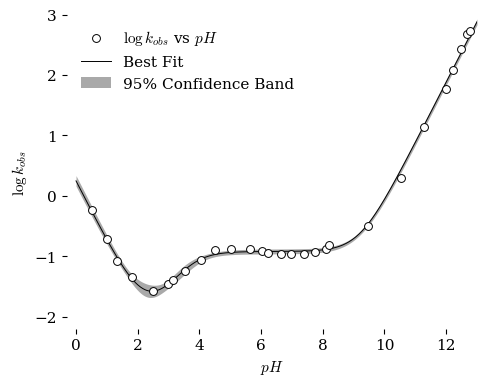

In [44]:
###############################################################################
# Plot
###############################################################################

################################################################################
### Setup a figure  and choose a stylesheet   
################################################################################
plt.rcdefaults()
plt.style.use(github_styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

ax.scatter(x, y, 
           marker = "o", s=32, 
           c="white", edgecolor = "black",
           linewidth = 0.7, label=r"$\log{k_{obs}}$ vs $pH$", zorder=4)



ax.plot(
    x_fit,
    y_fit,
    color="black",
    lw=0.7,
    label="Best Fit",
    zorder = 3
)

ax.fill_between(
    x_fit,
    ci_lower,
    ci_upper,
    linewidth = 0,
    facecolor="darkgray",
    edgecolor = "dimgray",
#    facecolor="lightskyblue",
#    edgecolor = "dodgerblue",
#    alpha=0.30,
    label="95% Confidence Band",
    zorder = 2

)

#ax.fill_between(
#    x_fit,
#    pi_lower,
#    pi_upper,
##    ls = "None",
#    linewidth = 0,
#    facecolor="gainsboro",
#    edgecolor = "darkgray",
##    facecolor="honeydew",
##    edgecolor = "lightgreen",
##    alpha=0.30,
#    label="95% Prediction Band",
#    zorder = 1
#)

ax.set(ylabel=r"$\log{k_{obs}}$", 
       xlabel=r"$pH$",
          xlim=[-0.3,13],                  
          ylim=[-2.2,3]
      )


plt.legend()
plt.tight_layout()
fig.savefig("plots/03_plot_LMFit_CI_PI.pdf")   # use this to save the figure in PDF format

plt.show()

### Prediction Interval

Successful fits: 5000/5000


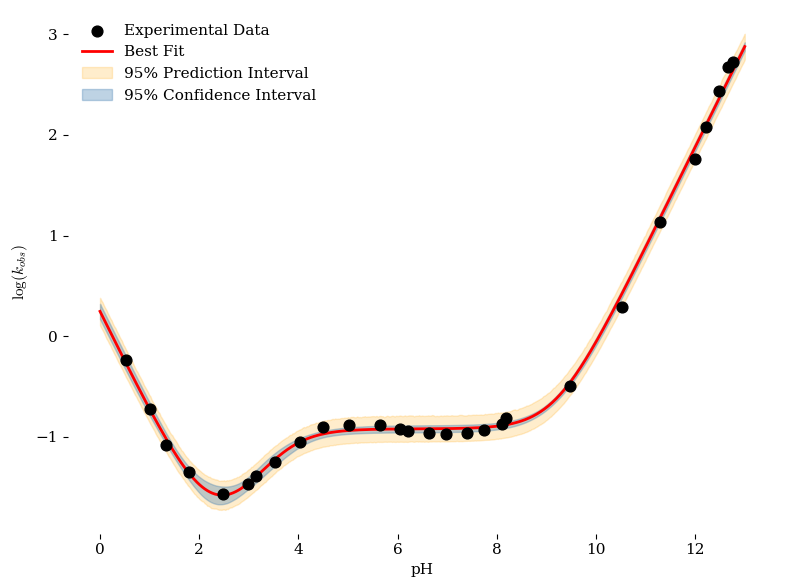

In [50]:
import numpy as np
import matplotlib.pyplot as plt

###############################################################################
# Bootstrap confidence and prediction bands
###############################################################################

nboot = 5000
seed = 123

rng = np.random.default_rng(seed)

###############################################################################
# Smooth pH grid
###############################################################################


###############################################################################
# Original fitted curve
###############################################################################

y_fit = result.eval(pH=x_fit)

###############################################################################
# Residuals from original fit
###############################################################################

residuals = (result.data - result.best_fit)

###############################################################################
# Storage
###############################################################################

curve_samples = []

successful = 0

###############################################################################
# Residual bootstrap
###############################################################################

for i in range(nboot):

    try:

        resampled_residuals = rng.choice(
            residuals,
            size=len(residuals),
            replace=True
        )

        y_boot = (
            result.best_fit
            + resampled_residuals
        )

        boot = gmodel.fit(
            y_boot,
            result.params.copy(),
            pH=x
        )

        curve = boot.eval(
            pH=x_fit
        )

        curve_samples.append(curve)

        successful += 1

    except Exception:
        pass

curve_samples = np.asarray(
    curve_samples
)

print(
    f"Successful fits: "
    f"{successful}/{nboot}"
)

###############################################################################
# 95% bootstrap confidence band
###############################################################################

ci_lower = np.percentile(
    curve_samples,
    2.5,
    axis=0
)

ci_upper = np.percentile(
    curve_samples,
    97.5,
    axis=0
)

prediction_samples = np.empty_like(
    curve_samples
)

for i in range(curve_samples.shape[0]):

    noise = rng.choice(
        residuals,
        size=len(pH_grid),
        replace=True
    )

    prediction_samples[i] = (
        curve_samples[i]
        + noise
    )
###############################################################################
# 95% prediction band
###############################################################################

pi_lower = np.percentile(
    prediction_samples,
    2.5,
    axis=0
)

pi_upper = np.percentile(
    prediction_samples,
    97.5,
    axis=0
)

###############################################################################
# Plot
###############################################################################

plt.figure(figsize=(8, 6))

# Experimental data

plt.scatter(
    x,
    y,
    color="black",
    s=60,
    zorder=10,
    label="Experimental Data"
)

# Best-fit curve

plt.plot(
    x_fit,
    y_fit,
    color="red",
    lw=2,
    label="Best Fit"
)

# Prediction interval (plot first)

plt.fill_between(
    x_fit,
    pi_lower,
    pi_upper,
    color="orange",
    alpha=0.20,
    label="95% Prediction Interval"
)

# Confidence interval

plt.fill_between(
    x_fit,
    ci_lower,
    ci_upper,
    color="steelblue",
    alpha=0.35,
    label="95% Confidence Interval"
)

plt.xlabel("pH")
plt.ylabel(r"$\log(k_{obs})$")

plt.legend()

plt.tight_layout()

plt.show()

In [51]:
resid_pi_lower = pi_lower - y_fit
resid_pi_upper = pi_upper - y_fit

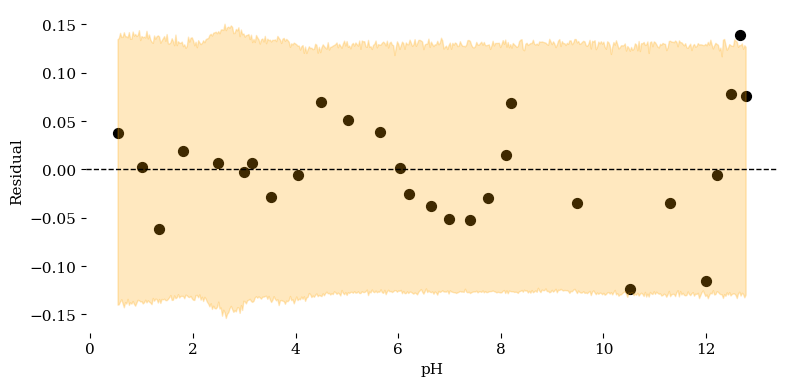

In [52]:
plt.figure(figsize=(8,4))

plt.scatter(
    x,
    y - result.best_fit,
    color='black',
    s=50
)

plt.fill_between(
    pH_grid,
    resid_pi_lower,
    resid_pi_upper,
    color='orange',
    alpha=0.25
)

plt.axhline(
    0,
    color='black',
    ls='--'
)

plt.xlabel("pH")
plt.ylabel("Residual")

plt.show()